# 1. 理解Vue的工作结构

## 1.1. 相关文件说明

### (1) package.json

- 主要是：
    - 配置一些执行指令。
    - 配置项目需要的模块。

### (2) src目录

- 是项目工程的所有代码与配置。
    - router目录：核心包含index.js用于配置页面访问路由。页面由views + components构成。
        - views目录：负责页面的主模版，主模版由components构成。
        - components目录：负责页面中各个组件的封装。
    - assets目录： 主要配置项目的图片，样式表等资产。
    - 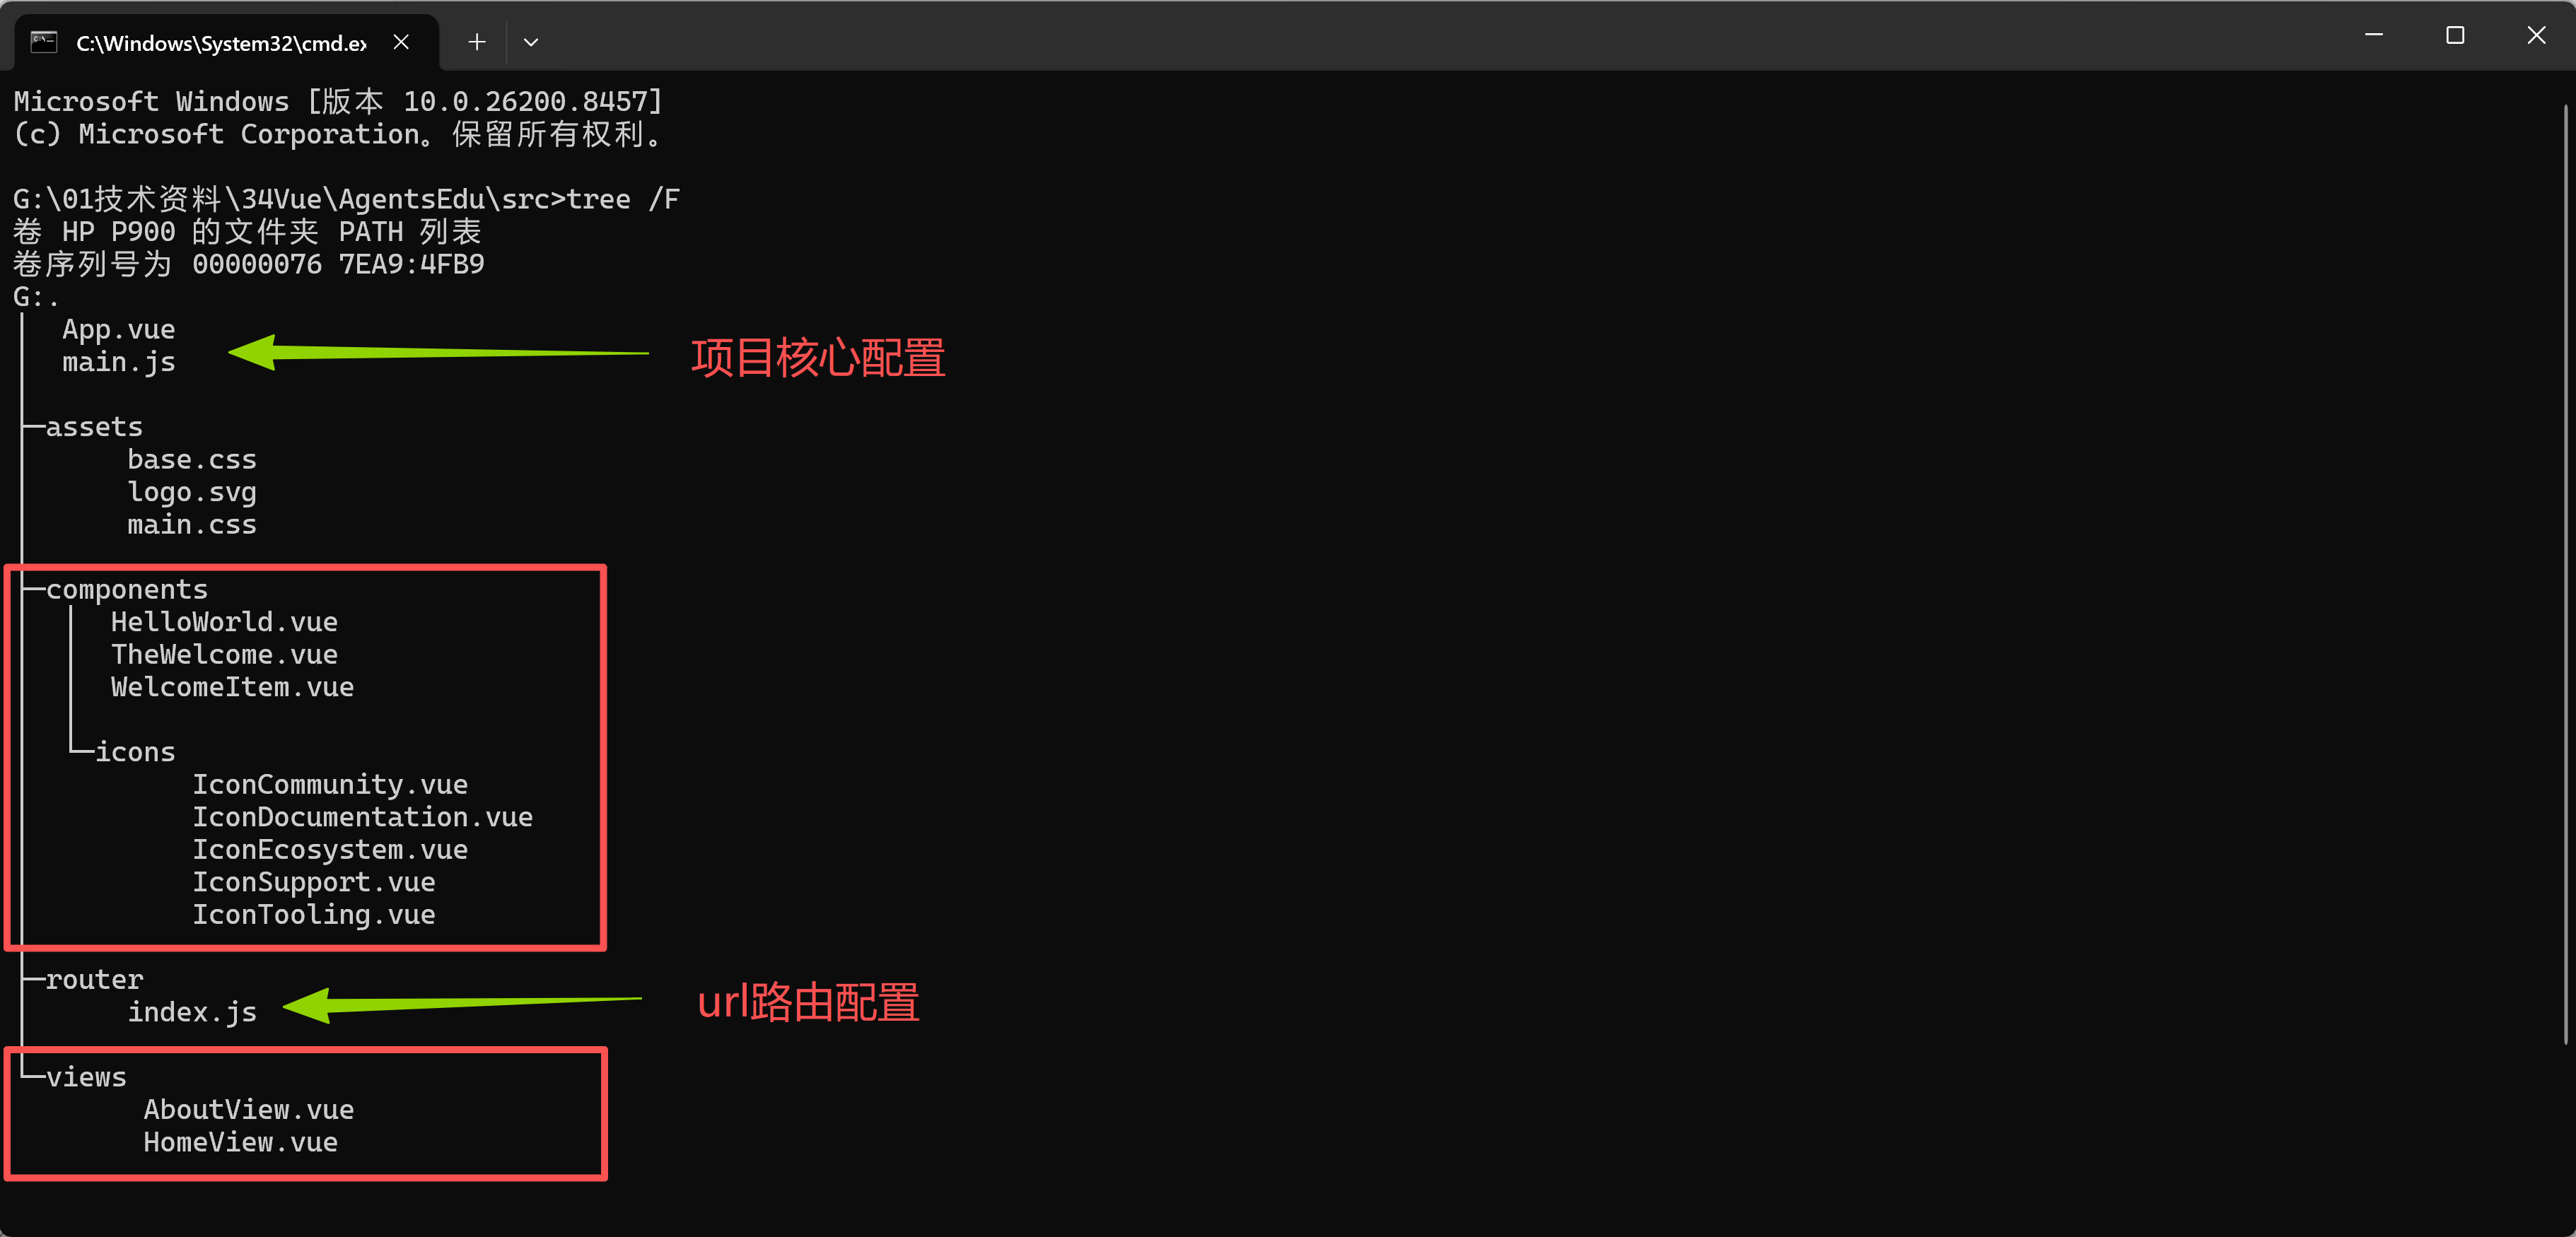

- 在src还有两个文件：
    - App.vue：主页的View。
        - 
    - main.js：项目代码的核心配置，也是项目执行的入口
        - app，路由，css的配置。
    - 

## 1.2. 文件与目录关系说明

- 简单关系
    - > 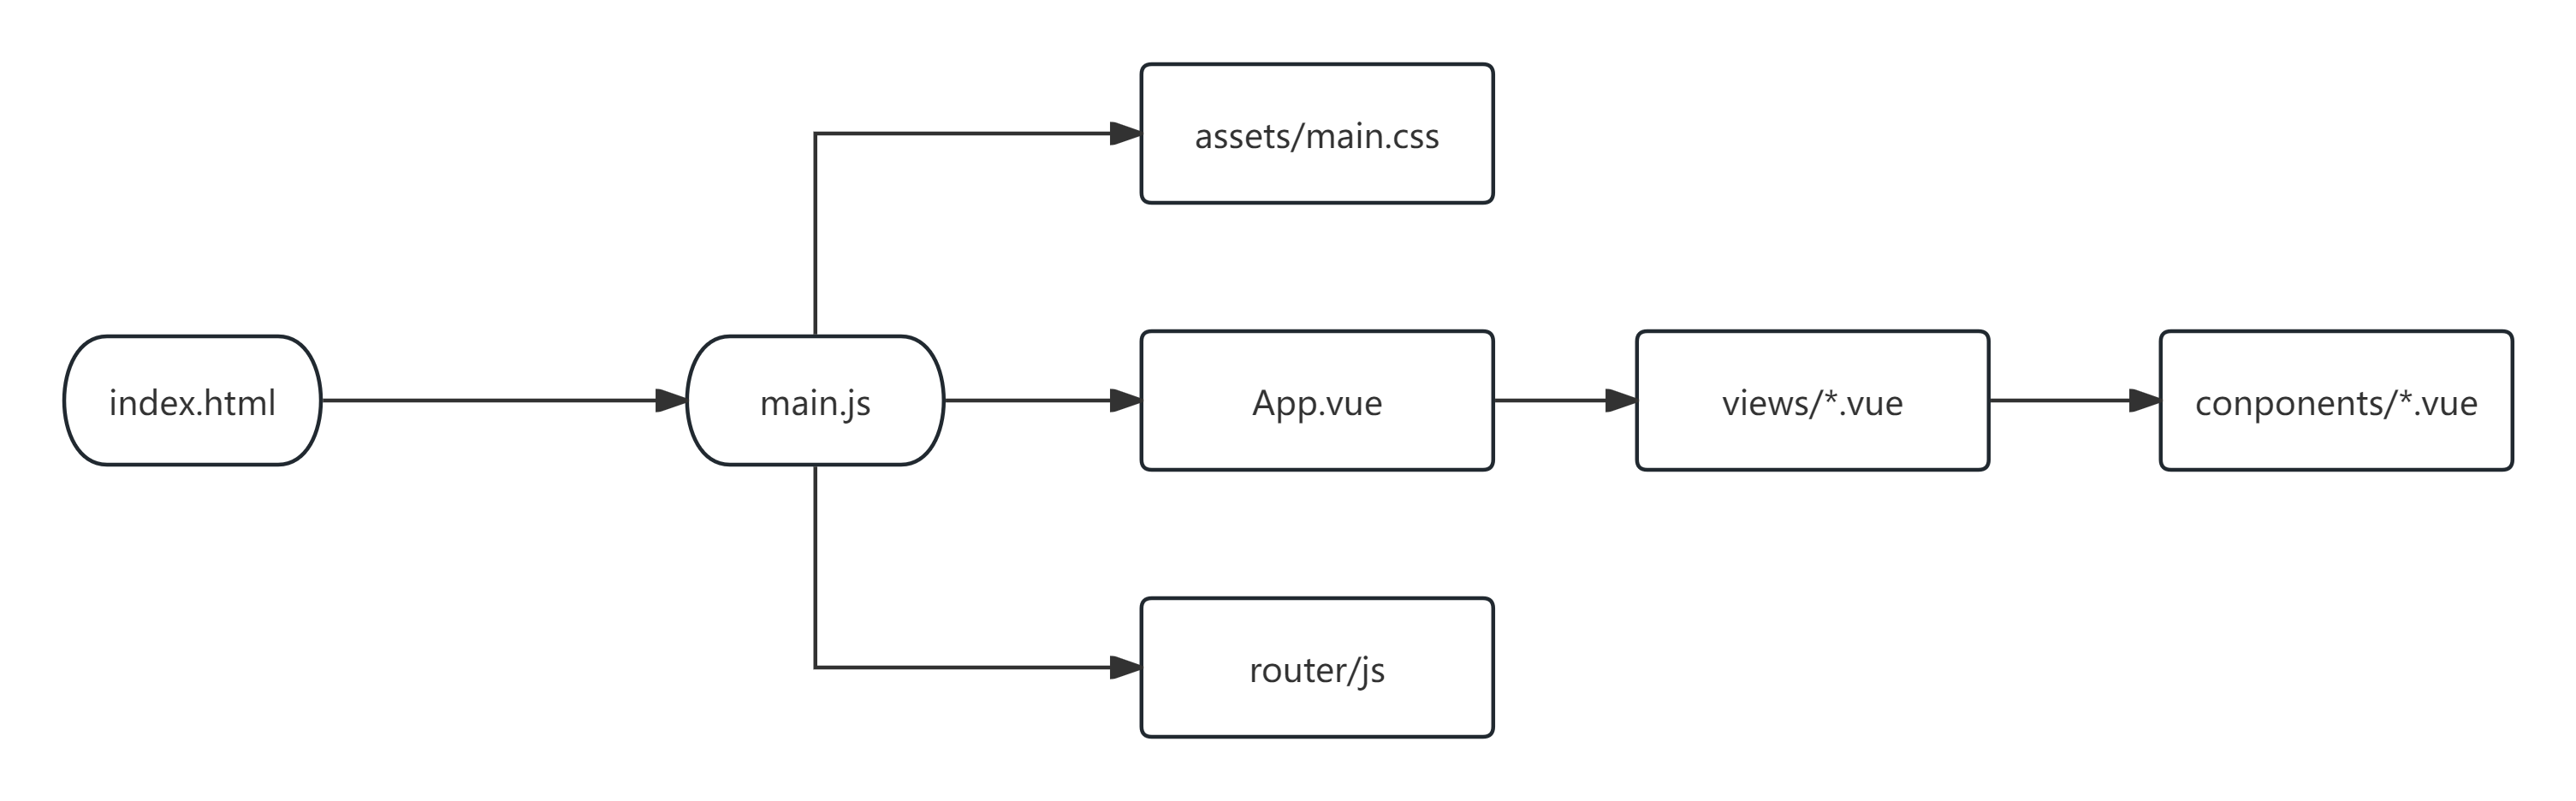

## 1.3. 删除原来页面文件

- 把原来创建的默认页面全部删除
    - 删除components目标下的所有vue文件
    - 删除views目录下所有vue文件
    - 删除assets目标base.css与logo.svg，保留main.css
        - 但是需要删除main.css的内容。只保留Tailwind样式有关的三个引入。 

- 删除文件后的项目结构如下图：
    - > 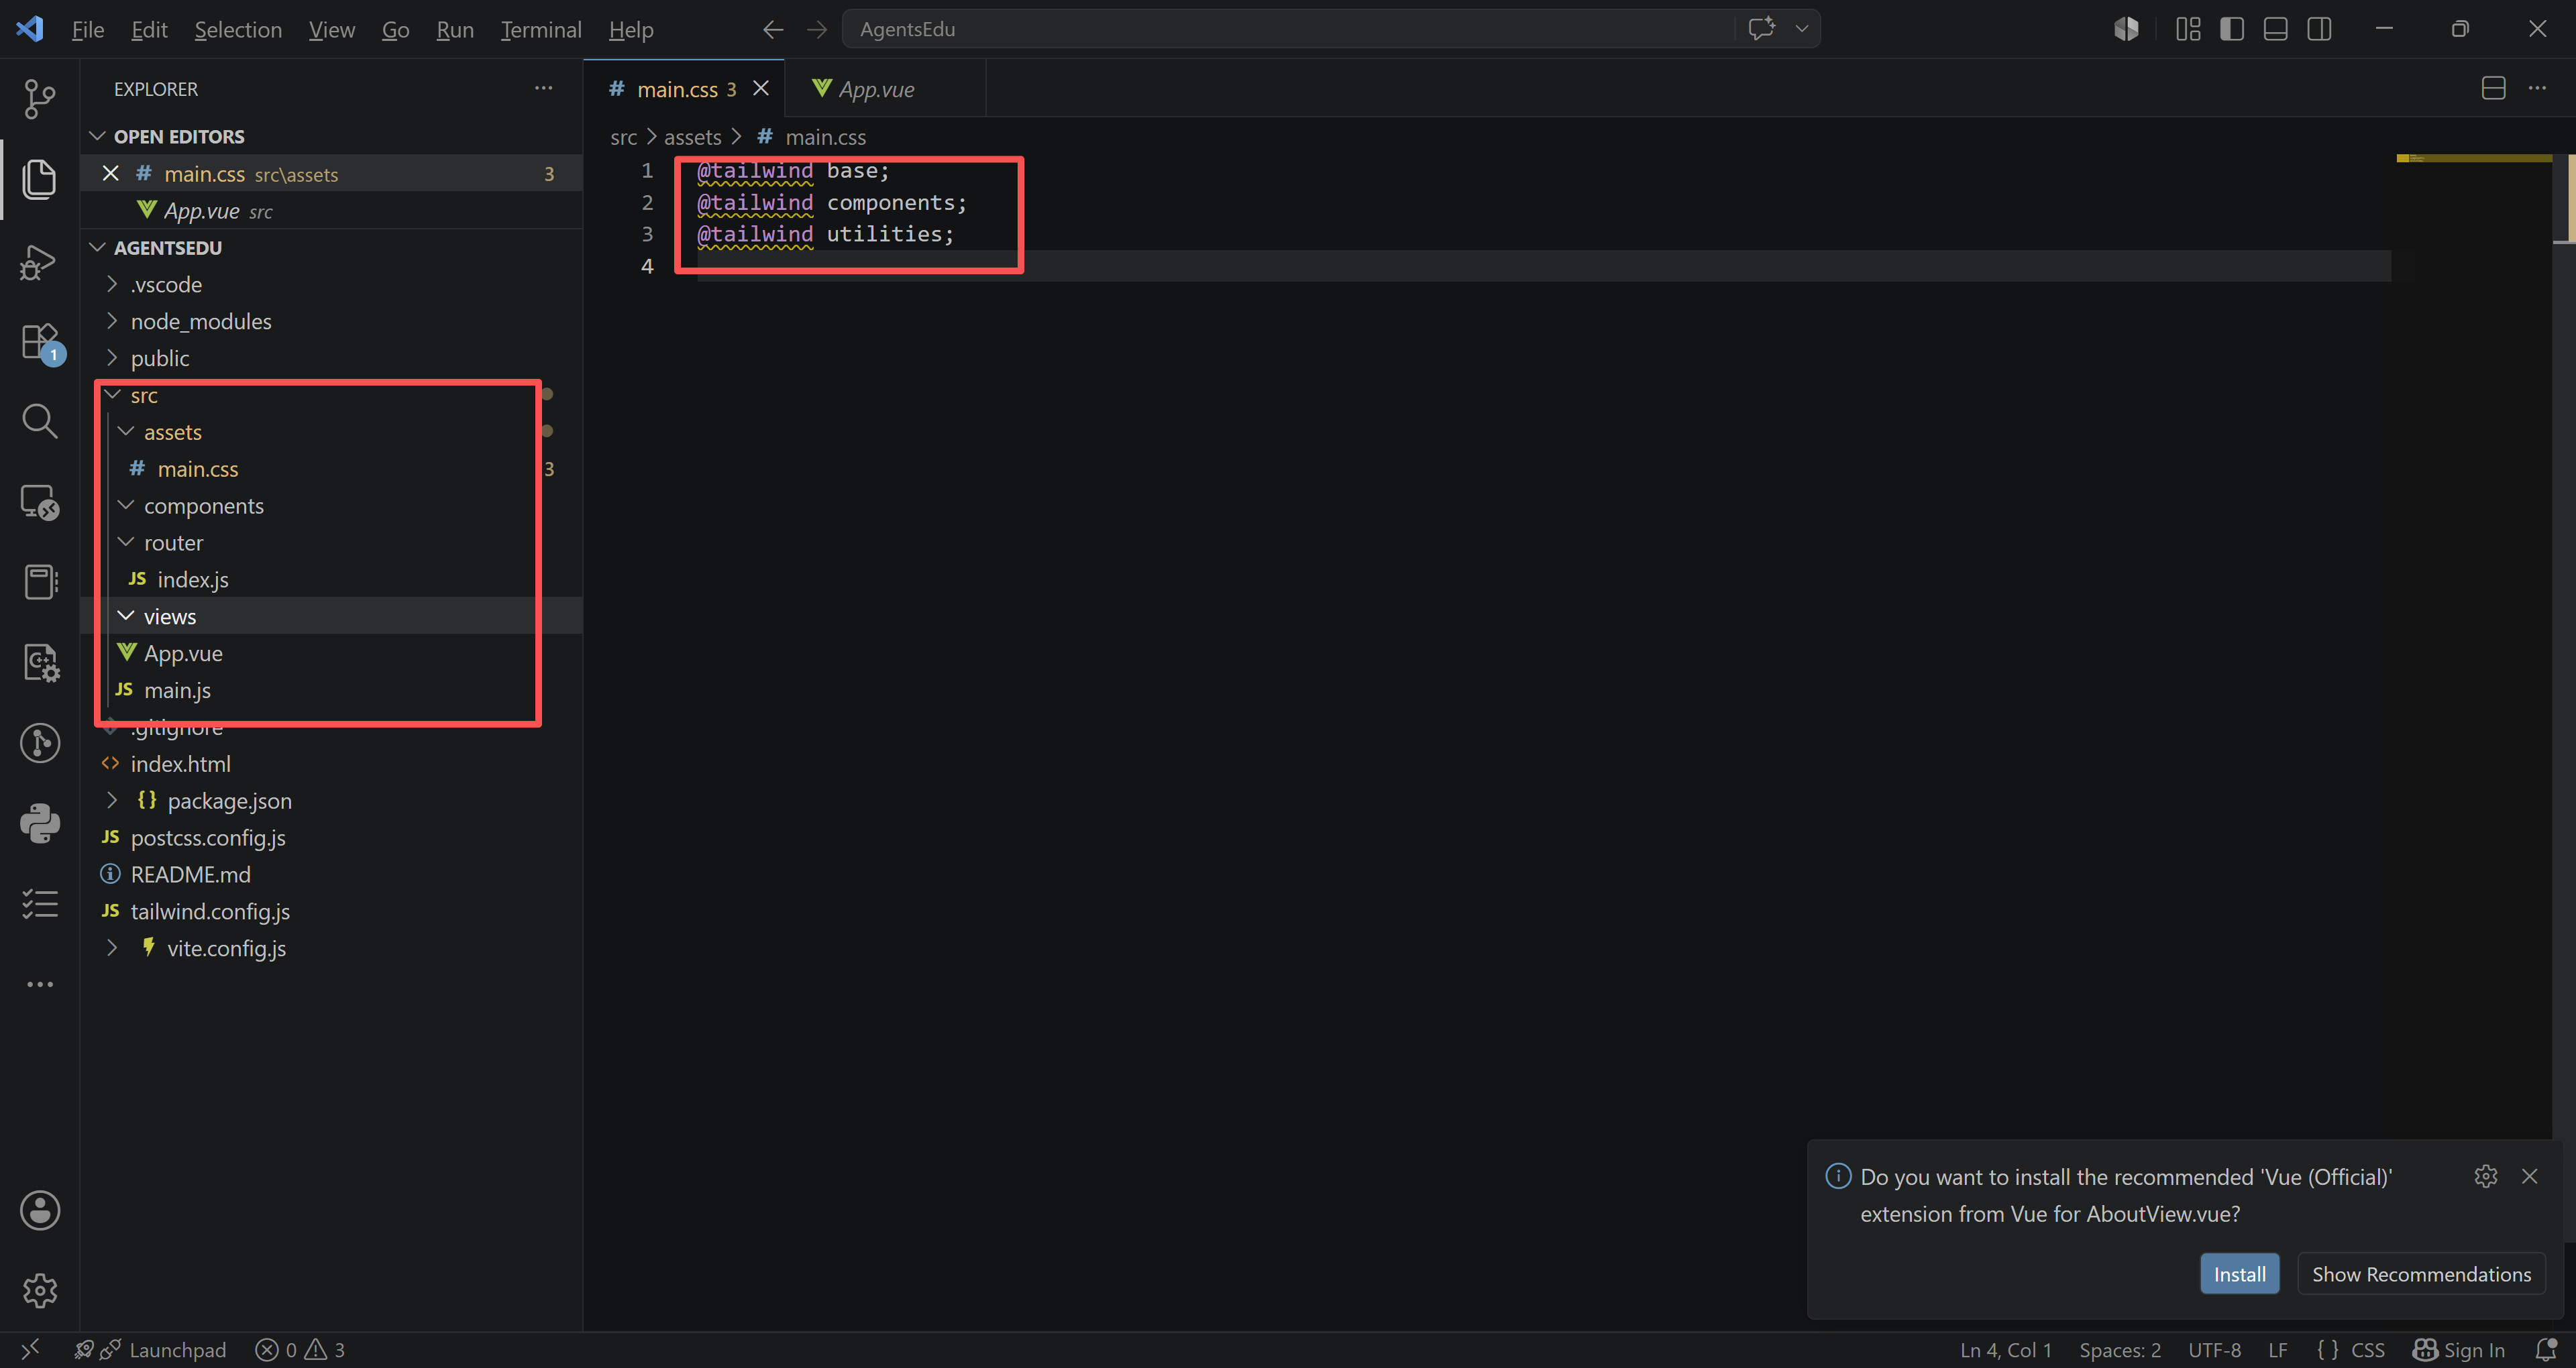

- 把index.js中相关路由也删除。

## 1.4. 页面模版说明

- 页面结构说明：
    - > 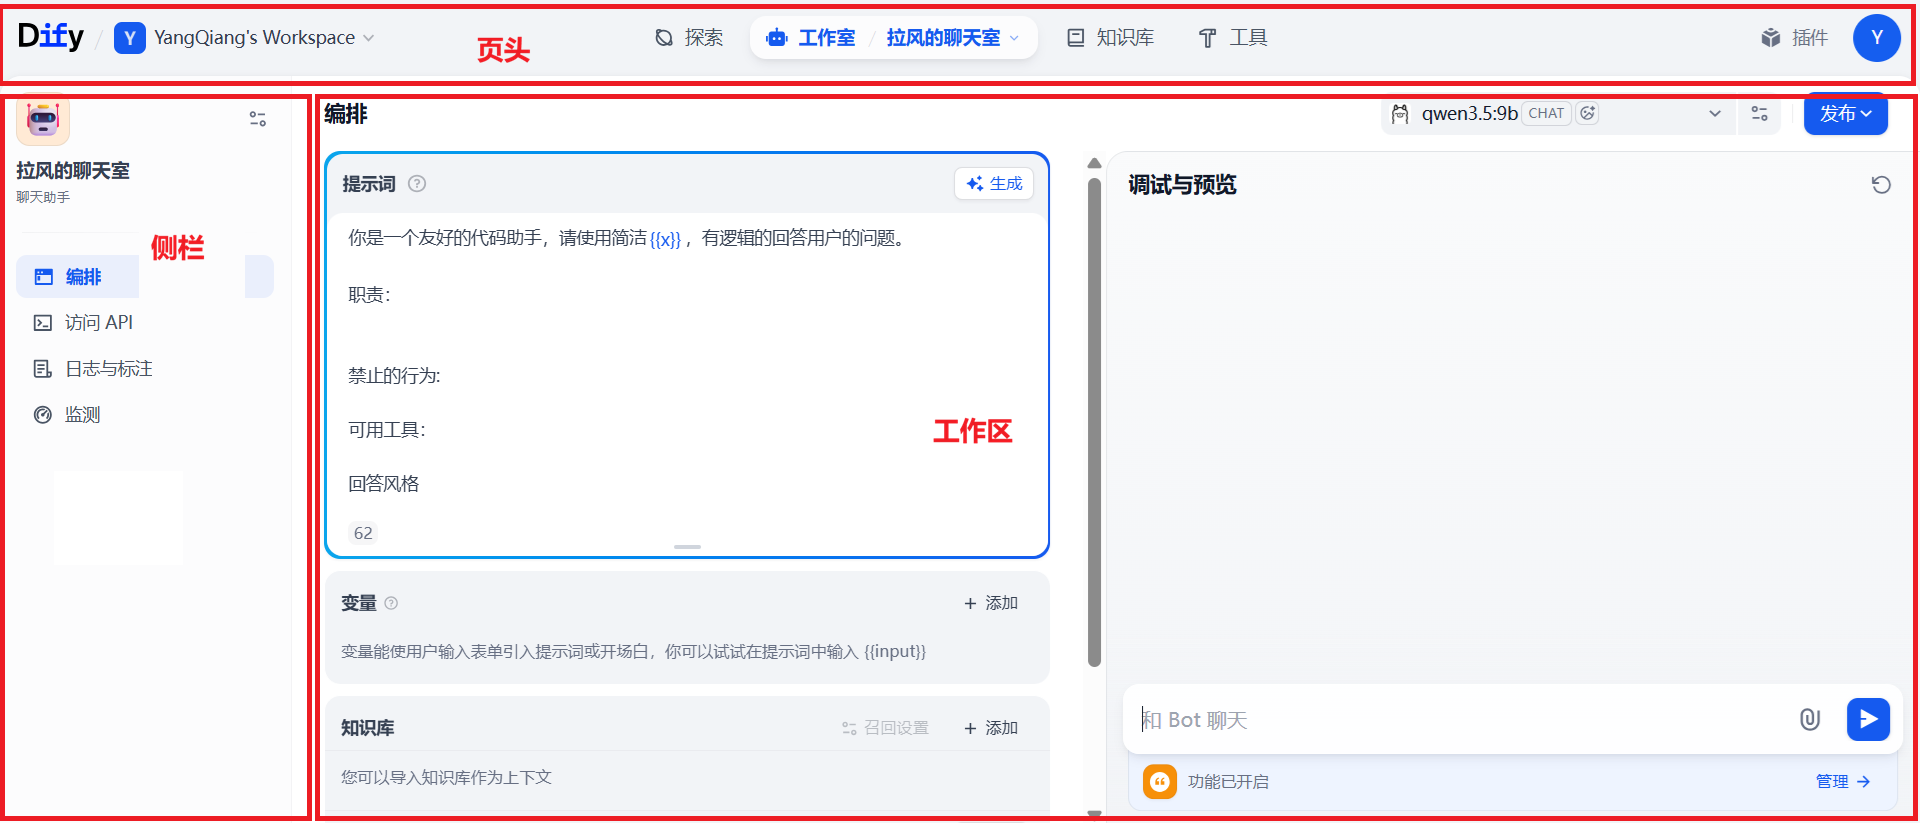

- 整个页面我们称为view，其中的页头，侧栏，工作区可以做成组件（头组件，侧栏组件，工作区组件）
    - 头与侧栏一般不会变动，可以在View模版中固定。
    - 工作区组件一般会根据不同业务而变动，我们可以使用路由器组件切换。
        - 路由器组件可以设置多级，从而无限嵌套。

# 2. 页面结构设计- 案例（Dify页面）

## 2.1. 改造主页

- 主页构成：
    - view：（一级路由）
        - App.vue
    - 组件：
        - header.vue
        - 工作区（使用二级路由）：（可选）

## 2.2. 使用截图+千问生成页面与组件

- 截图后稍微调整：
    - > 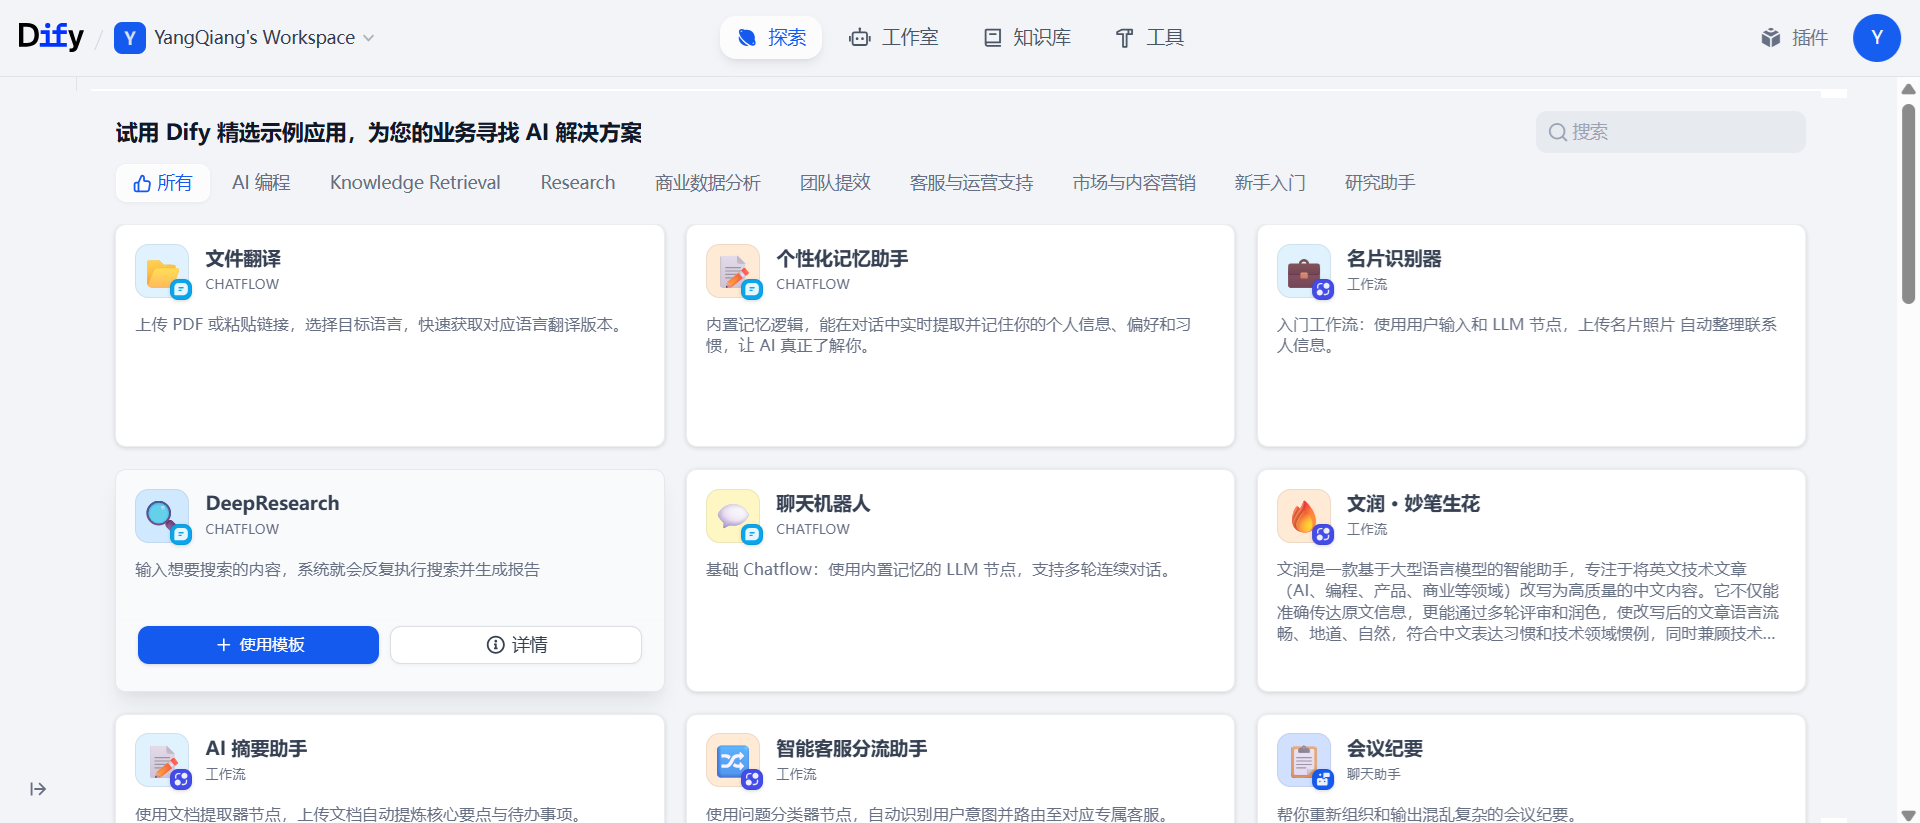

- 使用如下提示词生成组件vue
    - `使用Tailwind帮我生成vue页面组件，生成header组件模版与view模版以及整个主页面的模版，要求其中卡片也需要生成独立的vue组件模版，header组件中的导航需要居中，图标使用@lucide/vue`

- 千问生成四个独立的组件：
    - AppLayout.vue：主布局容器，包含顶部导航和主内容区。
    - AppHeader.vue：顶部导航栏组件。
    - Workspace.vue：工作区组件，负责网格布局和展示卡片列表。
    - AppCard.vue：通用的卡片组件。

### (1) 整体布局容器

```html
<!-- AppLayout.vue -->
<template>
  <div class="min-h-screen bg-gray-50 font-sans text-gray-900">
    <AppHeader />
    <Workspace />
  </div>
</template>

<script setup>
import AppHeader from './AppHeader.vue';
import Workspace from './Workspace.vue';
</script>
```

### (2) 顶部页面头与导航组件

```html
<!-- AppHeader.vue -->
<template>
  <header class="bg-white border-b border-gray-200 sticky top-0 z-50">
    <div class="max-w-7xl mx-auto px-4 sm:px-6 lg:px-8">
      <div class="flex justify-between h-16">
        <!-- 左侧：Logo & 导航 -->
        <div class="flex">
          <div class="flex-shrink-0 flex items-center gap-2">
            <div class="w-8 h-8 bg-indigo-600 rounded-lg flex items-center justify-center text-white font-bold">D</div>
            <span class="font-bold text-xl tracking-tight text-gray-900">Dify</span>
          </div>
          <nav class="hidden sm:ml-8 sm:flex sm:space-x-8">
            <a href="#" class="border-indigo-500 text-gray-900 inline-flex items-center px-1 pt-1 border-b-2 text-sm font-medium">
              探索
            </a>
            <a href="#" class="border-transparent text-gray-500 hover:border-gray-300 hover:text-gray-700 inline-flex items-center px-1 pt-1 border-b-2 text-sm font-medium">
              工作室
            </a>
            <a href="#" class="border-transparent text-gray-500 hover:border-gray-300 hover:text-gray-700 inline-flex items-center px-1 pt-1 border-b-2 text-sm font-medium">
              知识库
            </a>
          </nav>
        </div>

        <!-- 右侧：搜索 & 用户 -->
        <div class="flex items-center sm:ml-6 gap-4">
          <div class="relative hidden md:block">
            <div class="absolute inset-y-0 left-0 pl-3 flex items-center pointer-events-none">
              <svg class="h-4 w-4 text-gray-400" fill="none" viewBox="0 0 24 24" stroke="currentColor">
                <path stroke-linecap="round" stroke-linejoin="round" stroke-width="2" d="M21 21l-6-6m2-5a7 7 0 11-14 0 7 7 0 0114 0z" />
              </svg>
            </div>
            <input class="block w-full pl-10 pr-3 py-1.5 border border-gray-300 rounded-full leading-5 bg-gray-50 placeholder-gray-400 focus:outline-none focus:bg-white focus:ring-1 focus:ring-indigo-500 focus:border-indigo-500 sm:text-sm transition duration-150 ease-in-out" placeholder="搜索..." type="search">
          </div>
          <div class="flex items-center">
            <div class="h-8 w-8 rounded-full bg-indigo-100 flex items-center justify-center text-indigo-700 font-bold text-sm">
              Y
            </div>
          </div>
        </div>
      </div>
    </div>
  </header>
</template>
```

### (3) 工作区组件

```html
<!-- Workspace.vue -->
<template>
  <main class="bg-gray-50 min-h-screen pb-20">
    <div class="max-w-7xl mx-auto px-4 sm:px-6 lg:px-8 py-10">
      <!-- 标题区 -->
      <div class="mb-8">
        <h1 class="text-2xl font-bold text-gray-900">试用 Dify 精选示例应用</h1>
        <p class="mt-2 text-gray-500">为您的业务寻找 AI 解决方案</p>
      </div>

      <!-- 筛选标签 -->
      <div class="flex flex-wrap gap-2 mb-8">
        <button v-for="(tab, index) in tabs" :key="index"
          :class="[
            'px-4 py-1.5 rounded-full text-sm font-medium transition-colors',
            activeTab === tab
              ? 'bg-white text-indigo-600 shadow-sm ring-1 ring-inset ring-gray-300'
              : 'bg-transparent text-gray-600 hover:bg-gray-100'
          ]"
          @click="activeTab = tab"
        >
          {{ tab }}
        </button>
      </div>

      <!-- 卡片网格 -->
      <div class="grid grid-cols-1 gap-6 sm:grid-cols-2 lg:grid-cols-3">
        <AppCard
          v-for="(card, index) in filteredCards"
          :key="index"
          :title="card.title"
          :description="card.description"
          :tag="card.tag"
        >
          <!-- 如果需要传递自定义图标，可以在这里使用 slot -->
        </AppCard>
      </div>
    </div>
  </main>
</template>

<script setup>
import { ref, computed } from 'vue';
import AppCard from './AppCard.vue';

const activeTab = ref('所有');

const tabs = ['所有', 'AI 编程', 'Knowledge Retrieval', 'Research', '商业数据分析', '新手入门'];

// 模拟数据
const cards = ref([
  { title: '文件翻译', description: '上传 PDF 或粘贴链接，选择目标语言，快速获取对应语言翻译版本。', tag: 'CHATFLOW' },
  { title: '个性化记忆助手', description: '内置记忆逻辑，能在对话中实时提取并记住你的个人信息、偏好和习惯，让 AI 真正了解你。', tag: 'CHATFLOW' },
  { title: '名片识别器', description: '入门工作流：使用用户输入和 LLM 节点，上传名片照片自动整理联系人信息。', tag: '工作流' },
  { title: 'DeepResearch', description: '输入想要搜索的内容，系统就会反复执行搜索并生成报告', tag: 'CHATFLOW' },
  { title: '聊天机器人', description: '基础 Chatflow：使用内置记忆的 LLM 节点，支持多轮连续对话。', tag: 'CHATFLOW' },
  { title: '文润 · 妙笔生花', description: '专注于将英文技术文章改写为高质量的中文内容。它不仅能准确传达原文信息，更能通过多轮评审和润色...', tag: '工作流' },
]);

const filteredCards = computed(() => {
  if (activeTab.value === '所有') return cards.value;
  // 这里仅作演示，实际逻辑可能需要根据 tag 或 category 字段过滤
  return cards.value.filter(card => card.tag.includes(activeTab.value));
});
</script>
```

### (4) 卡片组件

```html
<!-- AppCard.vue -->
<template>
  <div class="group flex flex-col justify-between rounded-xl border border-gray-200 bg-white p-6 transition-all duration-200 hover:shadow-lg hover:-translate-y-1 h-full cursor-pointer">
    <!-- 顶部：图标与标签 -->
    <div class="flex justify-between items-start mb-4">
      <div class="flex items-center justify-center w-12 h-12 rounded-lg bg-blue-50 text-blue-600 group-hover:bg-blue-600 group-hover:text-white transition-colors">
        <!-- 这里使用了一个简单的 SVG 占位符，实际使用中可替换为 Icon 组件 -->
        <slot name="icon">
          <svg xmlns="http://www.w3.org/2000/svg" class="h-6 w-6" fill="none" viewBox="0 0 24 24" stroke="currentColor">
            <path stroke-linecap="round" stroke-linejoin="round" stroke-width="2" d="M13 10V3L4 14h7v7l9-11h-7z" />
          </svg>
        </slot>
      </div>
      <span v-if="tag" class="px-2.5 py-0.5 rounded-md text-xs font-medium bg-gray-100 text-gray-600 uppercase tracking-wide">
        {{ tag }}
      </span>
    </div>

    <!-- 中部：标题与描述 -->
    <div class="mb-4">
      <h3 class="text-lg font-bold text-gray-900 mb-2 group-hover:text-blue-600 transition-colors">{{ title }}</h3>
      <p class="text-sm text-gray-500 leading-relaxed line-clamp-3">
        {{ description }}
      </p>
    </div>

    <!-- 底部：操作按钮 (模拟图片中的按钮) -->
    <div class="mt-auto pt-4 border-t border-gray-50 flex gap-2">
      <button class="flex-1 px-4 py-2 bg-blue-600 hover:bg-blue-700 text-white text-sm font-medium rounded-lg transition-colors shadow-sm">
        使用模板
      </button>
      <button class="px-4 py-2 bg-white hover:bg-gray-50 text-gray-700 border border-gray-200 text-sm font-medium rounded-lg transition-colors">
        详情
      </button>
    </div>
  </div>
</template>

<script setup>
defineProps({
  title: { type: String, required: true },
  description: { type: String, required: true },
  tag: { type: String, default: '' }
});
</script>
```

## 2.3. 把千问生成的页面部署到项目工程中

- 从局部到全局的顺序把上面生成的内容导入项目工作。

### (1) 导入卡片组件

- 在components目录下创建`Card.vue`文件。并把上面生成的卡片组件的内容导入文件。

### (2) 导入工作区组件

- 在views目录下创建`AgentApp.vue`文件，并导入上面生成的工作区组件内容。
- 把其中卡片组件的路径修改成正确的路径与文件名。
    - `import AppCard from './components/Card.vue';`
    - 上面的AppCard可以随意命名。修改命名后，使用的组件名字也需要需要。
        - `import Card from './components/Card.vue'`

### (3) 导入页头组件

- 在components目录下，创建Header.vue文件，并把生成的页头与导航组件导入新创建的Header.vue文件。
    - 这个组件是叶子组件，没有引用其他组件，所以不需要修改引用组件的文件路径。

### (4) 导入容器布局组件

- 使用上面生成的容器组件内容，替代App.vue文件内容。
    - 容器布局组件使用了两个组件，所以需要修改其路径与文件名为正确的目录与文件名。

### (5) 修改index.html

- 根据需要，可以修改页面标题与图表
    - 图标：`<link rel="icon" href="/favicon.ico">`
    - 标题：`<title>教学智能体应用平台</title>`

### (6) 修改相关的URL路由配置

- 因为App.vue是自动挂载，而且默认是`/`
    - 下面的配置不是必须的。

```javascript
import { createRouter, createWebHistory } from 'vue-router'
import HomeView from '../App.vue'

const router = createRouter({
  history: createWebHistory(import.meta.env.BASE_URL),
  routes: [
    {
      path: '/',
      name: 'home',
      component: HomeView,
    },
  ],
})

export default router

```

- 引入正确的主页的组件：
    - `import HomeView from '../App.vue'`
- 配置主页的URL：
    - `path: '/',`
    - URL的命名可以包含定义的虚拟路径，以及任意的扩展名。

### (7) 运行项目

- 指令：
    - `npm run dev`

- 在浏览器访问：
    - `http://localhost:5173/`
        - > 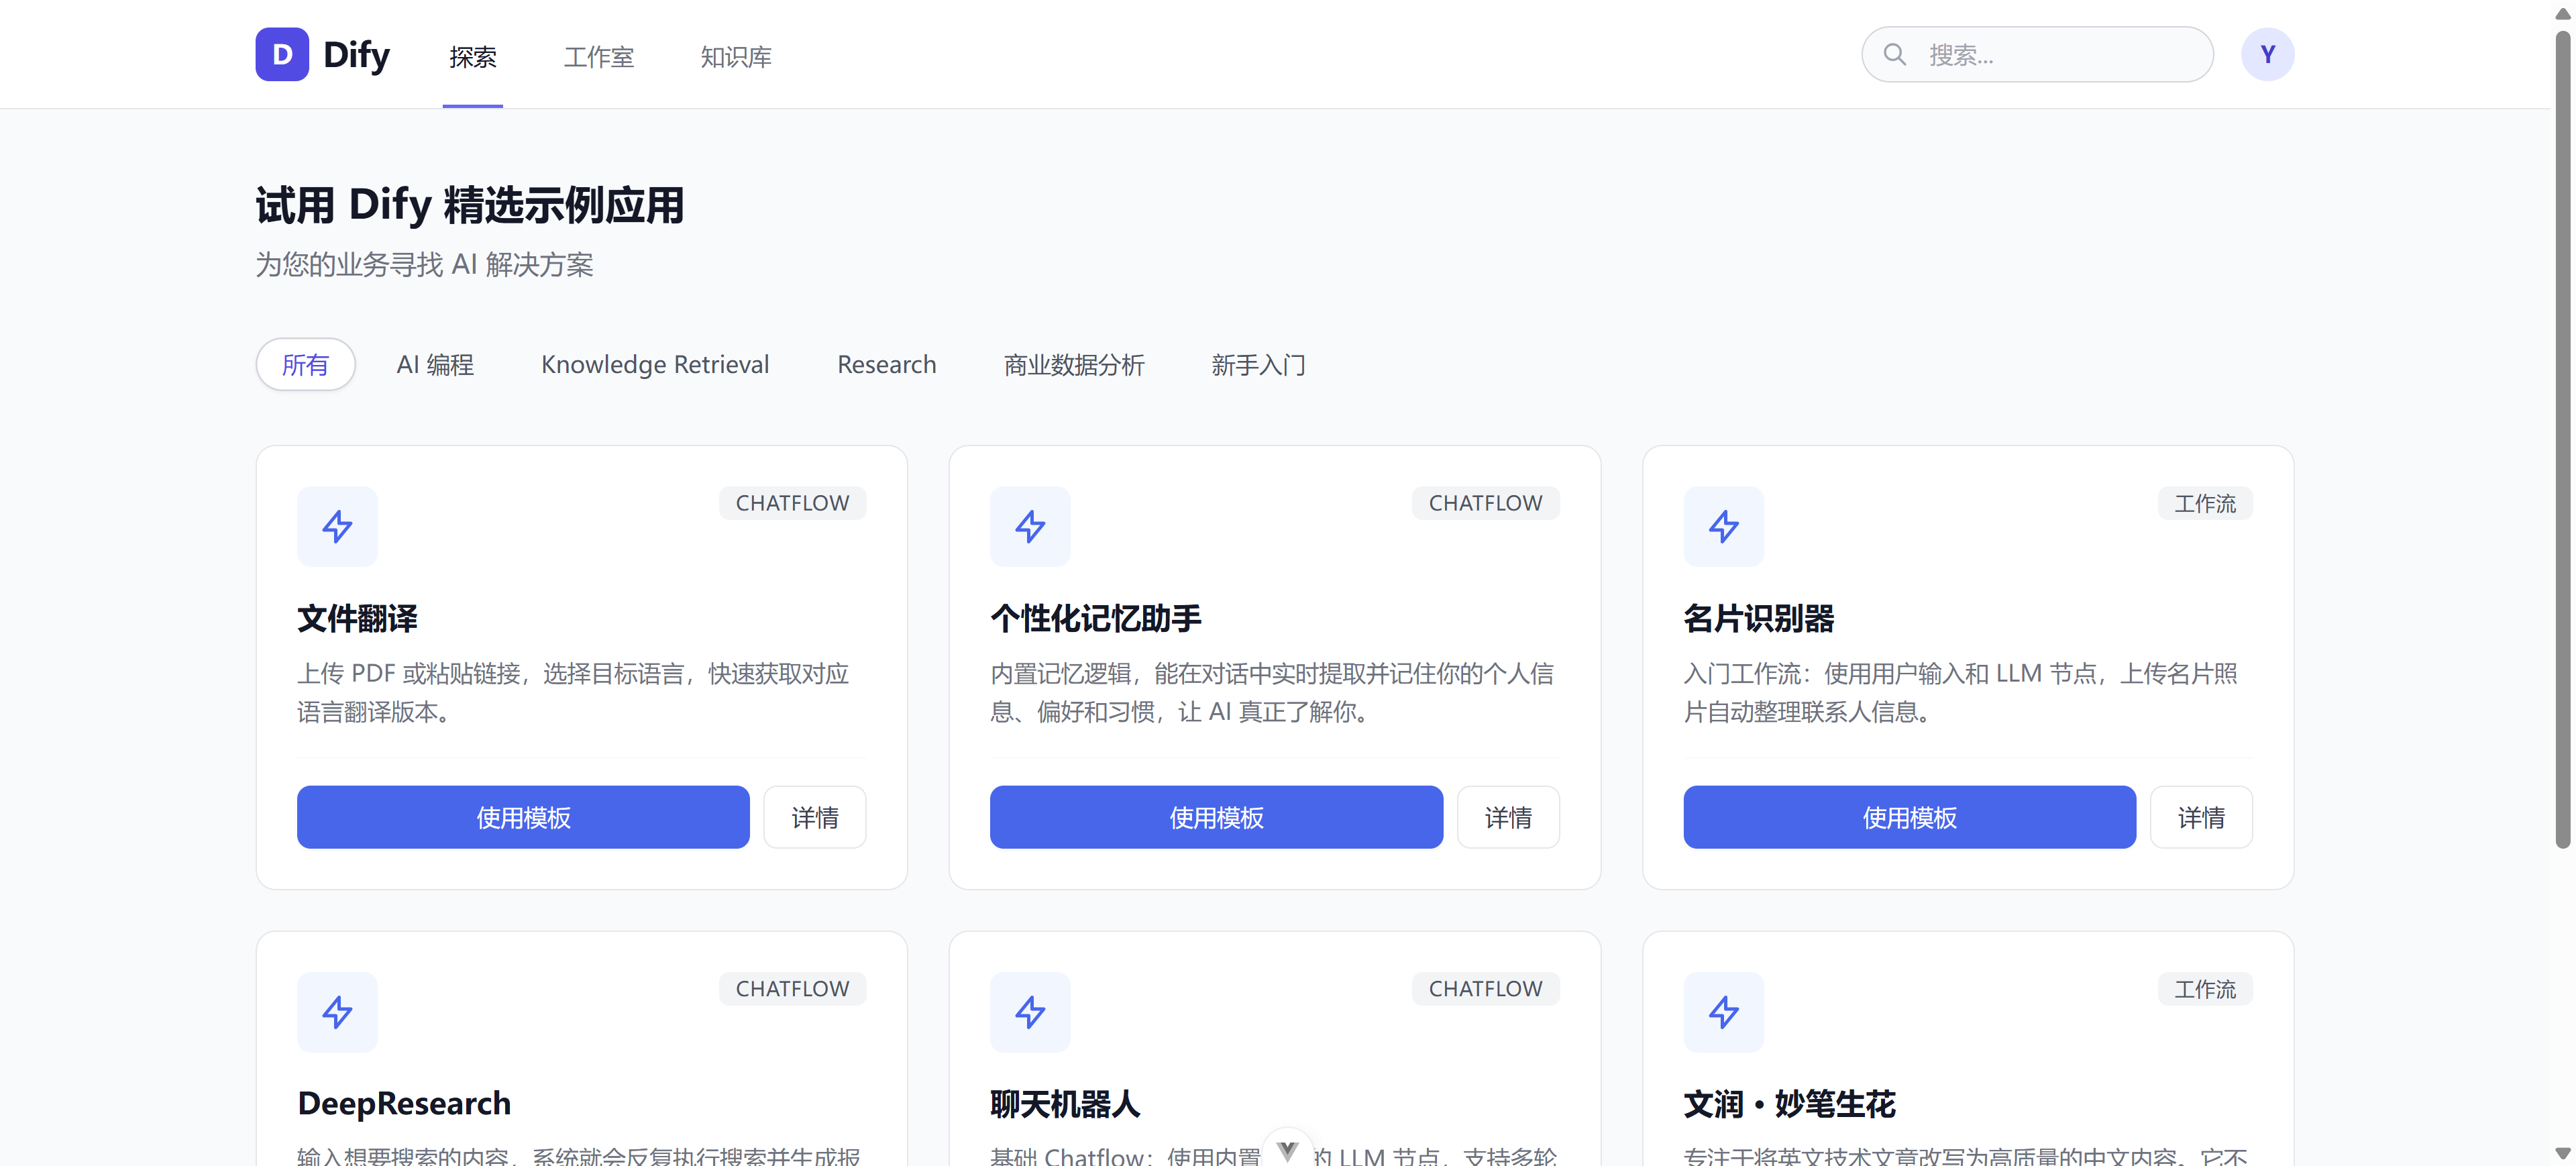

----

### **注意**

- 使用Vue实现的是纯前端，已经与后端无关。与后端的交互都是通过AJAX请求（已经封装组件）

- 页面微调。
    - Tailwind的样式表非常直观，可以对组件进行微调。
    - 可以微调交互效果。